In [548]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zafarali27/car-price-prediction/car_price_prediction_.csv
/kaggle/input/car-prices-dataset/train.csv
/kaggle/input/car-prices-dataset/test.csv


In [549]:
df=pd.read_csv('/kaggle/input/datasets/zafarali27/car-price-prediction/car_price_prediction_.csv')

In [550]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
1364,1365,Ford,2007,3.4,Electric,Automatic,15739,Like New,97090.31,Focus
1127,1128,Toyota,2004,1.9,Petrol,Automatic,132773,New,29737.34,Prius
1457,1458,Ford,2001,3.1,Diesel,Manual,214020,Like New,90105.17,Fiesta
831,832,Toyota,2008,5.2,Electric,Manual,18740,New,12929.83,Corolla
2163,2164,Mercedes,2006,3.1,Diesel,Manual,24815,New,31149.50,GLC


In [551]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
1664,1665,Mercedes,2017,4.6,Petrol,Automatic,131940,Like New,63165.20,C-Class
1485,1486,Mercedes,2017,5.4,Petrol,Automatic,256687,New,57601.95,E-Class
597,598,BMW,2019,3.2,Petrol,Manual,172438,Like New,94015.92,X5
1914,1915,BMW,2012,4.3,Petrol,Manual,63471,Used,65653.36,3 Series
1074,1075,Audi,2012,1.5,Petrol,Automatic,206096,Used,11200.65,Q7


In [552]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [553]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [554]:
df.drop('Car ID',axis=1,inplace=True)

In [555]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns

num_cols = num_cols.drop('Price')

In [556]:
num_cols

Index(['Year', 'Engine Size', 'Mileage'], dtype='object')

In [557]:
cat_cols

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

Year


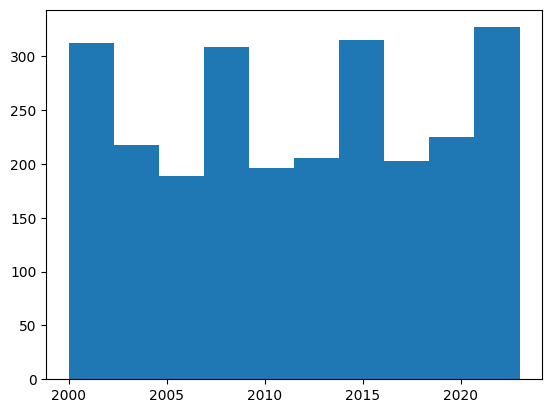

Engine Size


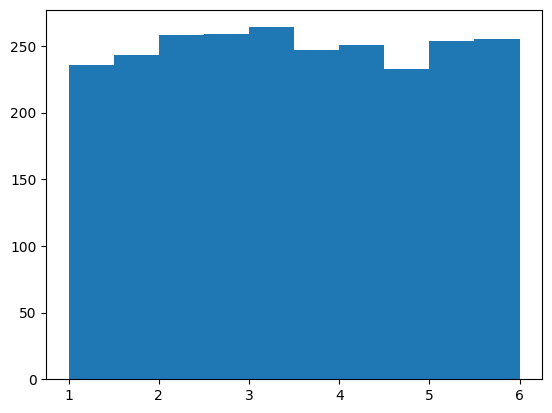

Mileage


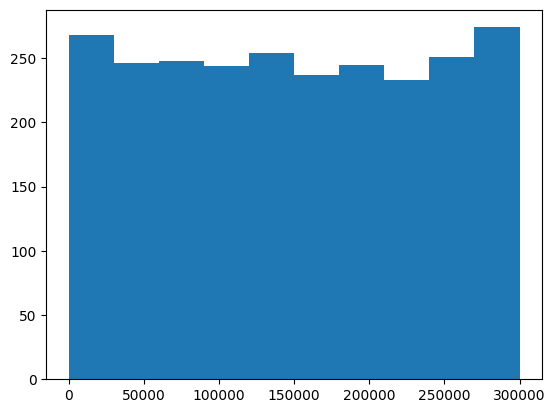

In [558]:
for i in num_cols:
    plt.hist(df[i],bins=10)
    print(i)
    plt.show()

In [559]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.impute import SimpleImputer

In [576]:
num_preprocessor=Pipeline(steps=[
    ('power transformer',PowerTransformer(method='yeo-johnson')),
    ('Scaling',StandardScaler()),
])

cat_preprocessor=Pipeline(steps=[
    #('ordinal_encoding', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)),
    ('OneHotEncoding',OneHotEncoder(sparse_output=False,drop='first')),
    ('Scaling',StandardScaler())
])

Here in the categorical columns if the value is ' - ' then it will handle it as -1 

In [577]:
preprocessor=ColumnTransformer(transformers=[
    ('numerical',num_preprocessor,num_cols),
    ('categorical',cat_preprocessor,cat_cols),
    
],remainder='passthrough',verbose_feature_names_out=True)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('power transformer',
                                                  PowerTransformer()),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['Year', 'Engine Size', 'Mileage'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('OneHotEncoding',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False)),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object'))])

In [578]:
x=df.drop(['Price'],axis=1)
y=df['Price']

In [579]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [580]:
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

In [581]:

x_train_p=preprocessor.fit_transform(x_train)
x_test_p=preprocessor.transform(x_test)
# Scale the target variable/
sc=StandardScaler()
y_train_p=sc.fit_transform(pd.DataFrame(y_train))
y_test_p=sc.transform(pd.DataFrame(y_test))


In [582]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 42)

rf.fit(x_train_p, y_train)

y_pred = rf.predict(x_test_p)

from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

-0.0925734832084304


# Label encoder is only used for target features and for the trianing features ordinal encoder is used

In [583]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [584]:
x_train_p

array([[-0.94028662,  0.01583287, -0.80549475, ..., -0.19044535,
        -0.19601428, -0.1876078 ],
       [-1.08333296, -1.34294452,  1.09637767, ..., -0.19044535,
        -0.19601428, -0.1876078 ],
       [-1.36916432,  1.55651836, -0.59537494, ..., -0.19044535,
        -0.19601428, -0.1876078 ],
       ...,
       [ 0.35105207, -0.12417832, -0.71171403, ...,  5.25085027,
        -0.19601428, -0.1876078 ],
       [-0.08017868,  0.94176045, -1.92840181, ..., -0.19044535,
        -0.19601428, -0.1876078 ],
       [-1.22629219,  0.68586772,  0.72000994, ..., -0.19044535,
        -0.19601428, -0.1876078 ]])

In [585]:
model=Sequential()

#model.add(Dense(256,activation='relu',input_shape=(x_train_p.shape[1],),kernel_initializer='he_uniform'))
BatchNormalization()


model.add(Dense(128,activation='relu',input_shape=(x_train_p.shape[1],),kernel_initializer='glorot_uniform',kernel_regularizer=regularizers.l2(0.005)))
model.add(Dropout(0.1))
model.add(BatchNormalization())

model.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
model.add(Dropout(0.1))
model.add(BatchNormalization())

model.add(Dense(32,activation='relu',kernel_regularizer=regularizers.l2(0.005)))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [586]:
model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_142 (Dense)               │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_121         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_122         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_123         │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_145 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,321 (63.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [587]:
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
earlystop=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
    )
reducelr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,#Reduce LR by 80% (new LR = old LR * 0.2)
    patience=15,
    min_lr=0.0001
)

In [588]:
model.compile(optimizer=Adam(0.005),loss='mean_squared_error',metrics=['r2_score'])

In [589]:
history=model.fit(x_train_p,y_train_p,batch_size=32,epochs=100,validation_split=0.1,verbose=1,callbacks=[earlystop,reducelr])

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.1261 - r2_score: -1.1595 - val_loss: 1.8700 - val_r2_score: -0.0115 - learning_rate: 0.0050
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1354 - r2_score: -0.1888 - val_loss: 1.7684 - val_r2_score: -0.0214 - learning_rate: 0.0050
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8746 - r2_score: -0.0417 - val_loss: 1.6435 - val_r2_score: -0.0149 - learning_rate: 0.0050
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6932 - r2_score: -0.0373 - val_loss: 1.5330 - val_r2_score: -0.0111 - learning_rate: 0.0050
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5482 - r2_score: 4.9727e-04 - val_loss: 1.4267 - val_r2_score: -2.9421e-04 - learning_rate: 0.0050
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4899 - r2_score: 0.0117 - val_loss: 1.3444 - val_r2_score: 0.0085 - learning_rate: 0.0050
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4354 - r2_score

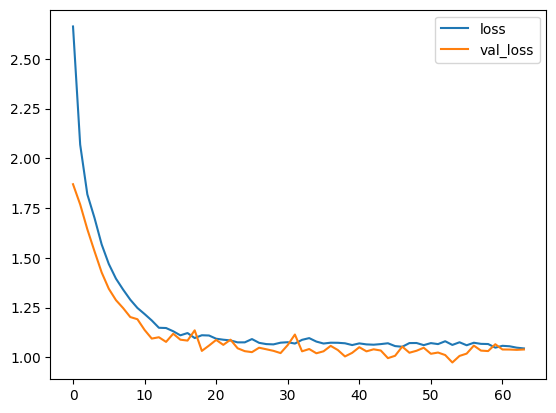

In [590]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()

In [591]:
from sklearn.metrics import r2_score

y_pred_scaled = model.predict(x_test_p)

y_pred = sc.inverse_transform(y_pred_scaled)

# 3. Calculate R2 using original y_test (unscaled) and your unscaled predictions
final_r2 = r2_score(y_test, y_pred)
print(f"Final R2 Score on Original Prices: {final_r2}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Final R2 Score on Original Prices: -0.04604055047562827
